### Colab setup

Run the cell below first. It installs the packages Colab does not ship with
(`numpy`, `scipy`, `sympy`, `matplotlib`, `pandas` and `scikit-learn` are
already there). Figures are
loaded from the course site, so this notebook needs a network connection --
the copy in the repo is the one to use offline.


In [ ]:
%pip install -q control


# PSE-823: Advanced Process Dynamics and Control
## Lecture 7 -- Frequency Response and Bode Diagrams
### (Coughanowr & LeBlanc, Ch. 15)

Date: __________

## Agenda

**Part A** -- The substitution rule: $s \to j\omega$ (Sec. 15.1)

**Part B** -- Bode diagrams: lags in series, resonance (Sec. 15.2)

**Part C** -- Controllers and dead time on the Bode diagram;
reading a frequency response from data (Sec. 15.2)

The thread of this lecture: a Bode diagram is first *measured* from
simulated sine-wave experiments, then *drawn* from the transfer
function -- and the two agree. Students read code and predict; the
instructor runs.

### Setup (run once)

- The standard imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import control as ct
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
plt.rcParams.update({"font.size": 15})

## Part A
### The Substitution Rule

(Coughanowr & LeBlanc, Ch. 15, Sec. 15.1)
<!-- source: coughanowr-ch15 -->

### Introduce -- a fortunate circumstance

- Lecture 3: the thermometer in a sinusoidal bath (Ex. 4.3) ends up
  oscillating at the **same frequency**, smaller and **later**.
- Amplitude ratio $AR = 1/\sqrt{1 + \omega^2\tau^2}$,
  phase $\phi = -\tan^{-1}\omega\tau$ -- found by partial fractions.
- Claim (Sec. 15.1): put $s = j\omega$ in $G(s)$; then
  $AR = |G(j\omega)|$ and $\phi = \angle G(j\omega)$.
- Valid for **stable** $G$ only: the transients must die out.

### Derive 1/3 -- first order (Eqs. 15.2-15.3)

$G(j\omega) = 1/(j\omega\tau + 1)$; multiply by the conjugate:

$$G(j\omega) = \frac{1}{1+\omega^2\tau^2} - j\frac{\omega\tau}{1+\omega^2\tau^2}
\;\Rightarrow\;
|G| = \frac{1}{\sqrt{1+\omega^2\tau^2}},\;\;
\angle G = \tan^{-1}(-\omega\tau)$$

Exactly Eq. 4.28.

### Derive 2/3 -- second order (Ex. 15.2, Eq. 15.4)

$s = j\omega$ in $1/(\tau^2s^2 + 2\zeta\tau s + 1)$:

$$AR = \frac{1}{\sqrt{(1-\omega^2\tau^2)^2 + (2\zeta\omega\tau)^2}},\quad
\phi = -\tan^{-1}\frac{2\zeta\omega\tau}{1-\omega^2\tau^2}$$

### Derive 3/3 -- series and dead time

Polar form: magnitudes multiply, angles add:

$$|G_1G_2\cdots| = |G_1||G_2|\cdots,\qquad
\angle G_1G_2\cdots = \angle G_1 + \angle G_2 + \cdots$$

Dead time $e^{-j\omega\tau}$: $AR = 1$, $\phi = -\omega\tau$ (Eq. 15.6).

### Code 1/3 -- the substitution, symbolically

- Mirrors Derive 1/3: put $s = j\omega$, take modulus and argument
- `sp.I` is $j$; modulus with `sp.Abs`, angle from Im/Re

In [2]:
w, tau = sp.symbols("omega tau", positive=True)
Gjw = 1 / (sp.I * w * tau + 1)
print(sp.simplify(sp.Abs(Gjw)))            # AR
print(sp.atan(sp.simplify(sp.im(Gjw) / sp.re(Gjw))))  # phase
print(sp.simplify(sp.re(Gjw)), "|", sp.simplify(sp.im(Gjw)))

1/sqrt(omega**2*tau**2 + 1)
-atan(omega*tau)
1/(omega**2*tau**2 + 1) | -omega*tau/(omega**2*tau**2 + 1)


**Code walkthrough.** `sp.I` is the imaginary unit (j to engineers). With omega and tau
declared positive, `sp.Abs` simplifies to 1/sqrt(omega^2 tau^2 + 1).
The angle is atan(Im/Re); SymPy prints -atan(omega tau): Eq. 15.3.
(The real part is positive here, so plain atan is the right branch.) The last line splits the
complex number into real and imaginary parts, 1/(1 + w^2 tau^2) and
-w tau/(1 + w^2 tau^2): Eq. 15.2, the conjugate step of the board.

### Code 2/3 -- Python complex numbers do it numerically

- Ex. 15.1: thermometer $\tau = 0.1$ min at $\omega = 20$ rad/min
- `abs` and `np.angle` on a complex number; `20j` is $20j$

In [3]:
G = 1 / (0.1 * 20j + 1)
print(f"G(20j) = {G:.3f}")
print(f"AR = {abs(G):.3f}, phase = {np.degrees(np.angle(G)):.1f} deg")

G(20j) = 0.200-0.400j
AR = 0.447, phase = -63.4 deg


**Code walkthrough.** Python has complex numbers built in: `20j` is 20 times the imaginary
unit, so `0.1 * 20j + 1` is 1 + 2j. `abs` gives the magnitude and
`np.angle` the argument in radians, converted with `np.degrees`.
Prints G(20j) = 0.200-0.400j, AR = 0.447 (= 1/sqrt 5) and phase =
-63.4 deg: Ex. 15.1, and Lecture 3's sinusoidal-bath answer.

### Code 3/3 -- Example 15.3 by the formula

- Mirrors Derive 2/3 with $\tau = 1$, $\zeta = 0.8$, input $3\sin 0.5t$

In [4]:
tau_v, zeta, w_v = 1.0, 0.8, 0.5
G = 1 / ((1j * w_v * tau_v)**2 + 2 * zeta * tau_v * 1j * w_v + 1)
AR, phi = abs(G), np.angle(G)
print(f"AR = {AR:.3f}, phase = {np.degrees(phi):.1f} deg")
print(f"ultimate output: {3*AR:.2f} sin(0.5 t {phi:+.3f})")

AR = 0.912, phase = -46.8 deg
ultimate output: 2.74 sin(0.5 t -0.818)


**Code walkthrough.** `(1j * w * tau)**2` is (j omega tau)^2 = -(omega tau)^2: Python does the
algebra of j. AR = 0.912 and phase = -46.8 deg, so the ultimate output
is 2.74 sin(0.5 t - 0.818): Ex. 15.3 (the book rounds AR to 0.91 and
gets 2.73). Next we measure the same two numbers from a simulation.

### Build on it -- measure AR and phase from a simulation

- Run the sine through $G$; fit $y \approx a\sin\omega t + b\cos\omega t$
- Then $AR = \sqrt{a^2 + b^2}/3$, phase $= \text{atan2}(b, a)$

In [5]:
G2 = ct.tf([1], [1, 2 * 0.8, 1])
t = np.linspace(0, 80, 8001)
y = ct.forced_response(G2, t, 3 * np.sin(0.5 * t)).outputs
late = t > 40                                  # transients gone
X = np.column_stack([np.sin(0.5 * t[late]), np.cos(0.5 * t[late])])
a, b = np.linalg.lstsq(X, y[late], rcond=None)[0]
print(f"measured AR = {np.hypot(a, b) / 3:.3f}, "
      f"phase = {np.degrees(np.arctan2(b, a)):.1f} deg")

measured AR = 0.912, phase = -46.8 deg


**Code walkthrough.** `forced_response` feeds 3 sin(0.5 t) into the second-order system for
80 s. Only the part after 40 s is kept, when the transient has decayed.
Any sinusoid of frequency 0.5 can be written a sin + b cos; the two
columns of X are those basis functions and `np.linalg.lstsq` finds the
a and b that fit best (least squares, as in Lecture 3's tau fit). Then
amplitude = hypot(a, b) and phase = atan2(b, a). Prints AR = 0.912,
phase = -46.8 deg: the experiment agrees with the substitution rule.

### Your Turn (8 min)

**Ex. 15.4.** Tank ($\tau_1 = 0.203$ min) then 2 ft of pipe
($\tau_2 = 0.0397$ min dead time); $T_i = 75 + 5\sin 46t$.

1. By hand: AR and phase of $T_m'/T_i'$ at $\omega = 46$ rad/min.
2. Read the code: what does this print (two decimals)?

```python
G = np.exp(-46j * 0.0397) / (1 + 46j * 0.203)
print(round(abs(G), 3), round(np.degrees(np.angle(G)), 1))
```

(1) Tank: AR = 1/sqrt(1 + 9.34^2) = 0.107, phase = -84 deg. Pipe: AR =
1, phase = -46(0.0397) = -1.83 rad = -105 deg (book: -104). Overall
AR 0.107, phase -188 deg: T_m = 170 + 0.53 sin(46 t - 188 deg).
(2) 0.106 171.5: the magnitude, and the angle wrapped into (-180, 180]
-- -188.5 deg is shown as +171.5 deg. A reason to accumulate phase
with `np.unwrap` (Part C).

### Check -- cold-call

Why does the substitution rule fail for an **unstable** $G(s)$, even
though $G(j\omega)$ can still be computed?

The rule describes the ultimate periodic response, which exists only
after the transient terms die out. For an unstable G the transient
grows without bound, so there is no "ultimate sinusoid" to measure
(Sec. 15.3 appendix).

## Part B
### Bode Diagrams

(Coughanowr & LeBlanc, Ch. 15, Sec. 15.2)
<!-- source: coughanowr-ch15 -->

### Introduce -- one picture for every frequency (Fig. 15-12)

- $\log AR$ against $\log\omega$, and $\phi$ against $\log\omega$.
- Log scale turns **products into sums**: lags in series just add.
- Decibels: $20\log_{10} AR$ ($AR = 0.1$ is $-20$ dB).

### Derive 1/3 -- first-order asymptotes (Fig. 15-13)

$\log AR = -\frac12\log[(\omega\tau)^2 + 1]$:

$\omega\tau \ll 1$: $AR \to 1$ (slope 0). $\;\omega\tau \gg 1$:
$\log AR \to -\log\omega\tau$ (slope $-1$). They meet at the
**corner** $\omega_c = 1/\tau$, where the true $AR = 0.707$ and
$\phi = -45^\circ$.

### Derive 2/3 -- lags in series (Ex. 15.6)

$G = \frac{1}{(s+1)(s+5)} = \frac{1/5}{(s+1)(0.2s+1)}$:

$$\log AR = \log\tfrac15 + \log AR_1 + \log AR_2$$

Asymptote slopes add: 0 below $\omega = 1$, $-1$ between 1 and 5,
$-2$ above 5. Phase: $0 \to -180^\circ$.

### Derive 3/3 -- second-order resonance (Eqs. 15.15-15.16)

Minimize the denominator of $AR^2$ over $\omega\tau$:

$$(\omega\tau)_{max} = \sqrt{1 - 2\zeta^2},\qquad
AR_{max} = \frac{1}{2\zeta\sqrt{1-\zeta^2}}\qquad (\zeta < 0.707)$$

$AR > 1$ is possible -- never for a first-order system.

### Code 1/3 -- resonance by differentiation

- Mirrors Derive 3/3: $AR$ is largest where its denominator is smallest

In [6]:
z, x = sp.symbols("zeta x", positive=True)       # x = omega tau
D = (1 - x**2)**2 + (2 * z * x)**2               # 1 / AR^2
x_max = sp.solve(sp.diff(D, x), x)
print("omega tau at max:", x_max)
print("AR max:", sp.simplify(1 / sp.sqrt(D.subs(x, x_max[0]))))

omega tau at max: [sqrt(1 - 2*zeta**2)]
AR max: 1/(2*zeta*sqrt(1 - zeta**2))


**Code walkthrough.** `D` is the expression under the square root in Eq. 15.4, so AR is
largest where D is smallest. Differentiate, set to zero and solve: the
positive root is sqrt(1 - 2 zeta^2), Eq. 15.15 (it exists only for
zeta < 0.707). Substituting back and simplifying gives
1/(2 zeta sqrt(1 - zeta^2)), the peak plotted in Fig. 15-19.

### Code 2/3 -- Example 15.6: check the asymptote slopes

- Mirrors Derive 2/3; slope = change in $\log AR$ per decade

In [7]:
G6 = ct.tf([1], [1, 6, 5])                     # 1/((s+1)(s+5))
for lo, hi in [(0.01, 0.1), (1.5, 3.0), (50, 500)]:
    a_lo = abs(G6(1j * lo)); a_hi = abs(G6(1j * hi))
    slope = np.log10(a_hi / a_lo) / np.log10(hi / lo)
    print(f"omega {lo:5} to {hi:5}: slope {slope:+.2f}")
print(f"low-frequency AR = {abs(G6(1e-4j)):.3f} (gain 1/5)")

omega  0.01 to   0.1: slope -0.00
omega   1.5 to   3.0: slope -0.97
omega    50 to   500: slope -2.00
low-frequency AR = 0.200 (gain 1/5)


**Code walkthrough.** Calling a python-control transfer function with a complex number,
`G6(1j * w)`, evaluates G(j omega) directly. For each frequency band the
slope is the change in log10 AR divided by the change in log10 omega.
Expected: 0.00 well below 1, -0.97 between the corners (close to
-1; the band sits near both corners, so not exactly), -2.00 far above
5. The low-frequency AR is 0.200, the gain 1/5 that shifts the whole
curve down.

### Code 3/3 -- the second-order family (Fig. 15-17)

- One curve per $\zeta$; peaks appear for $\zeta < 0.707$

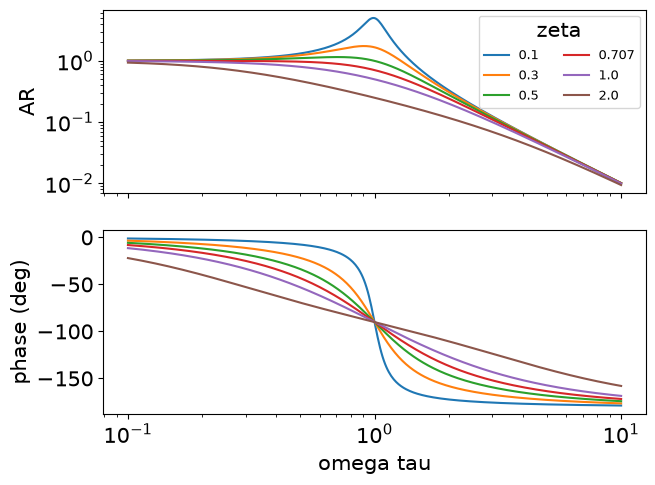

In [8]:
x = np.logspace(-1, 1, 400)                    # omega tau
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7, 5.25), sharex=True)
for zv in [0.1, 0.3, 0.5, 0.707, 1.0, 2.0]:
    G = 1 / ((1j * x)**2 + 2 * zv * 1j * x + 1)
    a1.loglog(x, abs(G), label=zv)
    a2.semilogx(x, np.degrees(np.unwrap(np.angle(G))))
a1.set_ylabel("AR"); a2.set(xlabel="omega tau", ylabel="phase (deg)")
a1.legend(title="zeta", fontsize=9, ncol=2); plt.show()

**Code walkthrough.** The formula is evaluated directly with NumPy complex arithmetic on a
log-spaced grid of omega tau. `loglog` and `semilogx` give log axes.
`np.unwrap` removes jumps of 360 deg so the phase falls smoothly from
0 to -180. Read it: every phase curve passes -90 deg at omega tau = 1;
for zeta < 0.707 the AR rises above 1 near omega tau = 1 (resonance:
a peak of about 5 for zeta = 0.1, from Code 1/3's formula); every curve
ends on the slope -2 asymptote.

### Build on it -- a Bode diagram measured from experiments

- Repeat Part A's sine experiment at 12 frequencies for Ex. 15.6
- Dots: measured. Line: $|G(j\omega)|$ from the transfer function

In [9]:
def measure(G, w, cycles=30, n=4000):
    t = np.linspace(0, cycles * 2 * np.pi / w, n)
    y = ct.forced_response(G, t, np.sin(w * t)).outputs
    late = t > t[-1] / 2
    X = np.column_stack([np.sin(w*t[late]), np.cos(w*t[late])])
    a, b = np.linalg.lstsq(X, y[late], rcond=None)[0]
    return np.hypot(a, b), np.degrees(np.arctan2(b, a))
w_exp = np.logspace(-1, 1.5, 12)
data = np.array([measure(G6, w) for w in w_exp])
print(np.round(data[:4], 4))

[[  0.1989  -6.8564]
 [  0.1971 -11.5122]
 [  0.192  -19.1572]
 [  0.1794 -31.1616]]


**Code walkthrough.** `measure` wraps Part A's experiment: run a unit sine of frequency w for
30 cycles, keep the second half, fit a sin + b cos, return (AR, phase).
The time span scales with 1/w so every frequency gets the same number
of cycles. Twelve log-spaced frequencies from 0.1 to 31.6 rad/time are
"tested". The printed first rows show AR near 0.2 and small phase lags
at low frequency, as the gain 1/5 predicts. The next cell plots all
twelve against the transfer function.

### Plot -- measured dots on the calculated curve

- If the dots sit on the line, $s = j\omega$ is confirmed by experiment

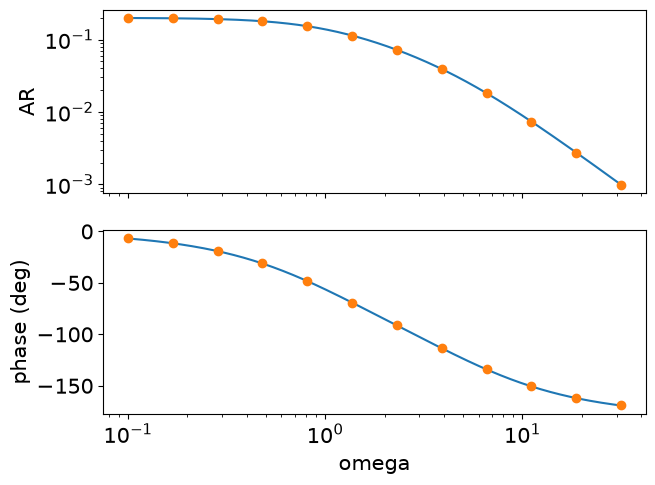

In [10]:
ww = np.logspace(-1, 1.5, 300)
Gw = 1 / ((1j * ww + 1) * (1j * ww + 5))
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7, 5.25), sharex=True)
a1.loglog(ww, abs(Gw)); a1.loglog(w_exp, data[:, 0], "o")
a2.semilogx(ww, np.degrees(np.unwrap(np.angle(Gw))))
a2.semilogx(w_exp, data[:, 1], "o")
a1.set_ylabel("AR"); a2.set(xlabel="omega", ylabel="phase (deg)")
plt.show()

**Code walkthrough.** Lines: AR and phase of 1/((j omega + 1)(j omega + 5)) computed directly.
Dots: the twelve simulated experiments. They coincide at every
frequency -- the Bode diagram can be *measured* on a plant (sine tests,
Prob. 15.2) before any model exists. The phase dots stop near -170 deg
at the highest frequency, approaching the -180 asymptote.

### Your Turn (8 min)

**Prob. 15.1(a).** $G = 100/[(10s + 1)(s + 1)]$.

1. By hand: the asymptote slopes and the corners; the AR and phase at
   $\omega = 10$.
2. Read the code: what does this print?

```python
print(20 * np.log10(0.1), 20 * np.log10(abs(1 / (1 + 1j))))
```

(1) Corners at 0.1 and 1; slopes 0, -1, -2. At omega = 10:
|10j(10) + 1| = 100.0 and |10j + 1| = 10.05, so AR = 100/1005 = 0.0995;
phase = -(89.4 + 84.3) = -173.7 deg. Slip: using 10 instead of 100 for
the first factor.
(2) -20.0 and about -3.01: AR = 0.1 is -20 dB; the first-order corner
value 0.707 is -3 dB.

### Check -- poll

Three first-order lags in series. At high frequency the AR asymptote
has slope ... and the phase approaches ...

**A)** $-1$, $-90^\circ$  **B)** $-3$, $-270^\circ$
**C)** $-3$, $-180^\circ$

B. Slopes add (-1 each) and phases add (-90 each). A system with three
or more lags can therefore reach -180 deg at a finite frequency -- the
ingredient for instability in Lecture 8.

## Part C
### Controllers and Dead Time on the Bode Diagram

(Coughanowr & LeBlanc, Ch. 15, Sec. 15.2)
<!-- source: coughanowr-ch15 -->

### Introduce -- the controller is a block too

- P: $AR = K_c$, $\phi = 0$.
- PI: low-frequency AR grows without bound -- that is what removes
  offset; it costs phase lag.
- PD: **phase lead**; can push the $-180^\circ$ point to higher
  frequency (stabilizing).
- Dead time: $AR = 1$, but phase lag grows without bound.

### Derive 1/2 -- PI and PD frequency responses

$s = j\omega$ in $K_c(1 + 1/\tau_Is)$ and $K_c(1 + \tau_Ds)$:

$$PI:\; AR = K_c\sqrt{1 + \frac{1}{(\omega\tau_I)^2}},\;
\phi = -\tan^{-1}\frac{1}{\omega\tau_I}\qquad
PD:\; AR = K_c\sqrt{1 + (\omega\tau_D)^2},\;
\phi = +\tan^{-1}\omega\tau_D$$

### Derive 2/2 -- Example 15.7, piece by piece

PD control of three lags, dead time in the measurement:

$$G = \frac{10(0.5s+1)e^{-s/10}}{(s+1)^2(0.1s+1)}:\quad
\phi = \tan^{-1}0.5\omega - 2\tan^{-1}\omega - \tan^{-1}0.1\omega
- 0.1\omega$$

Each factor's phase is computed alone, then summed.

### Code 1/2 -- PI and PD at their corners

- Mirrors Derive 1/2 at $\omega\tau = 1$ with $K_c = 1$

In [11]:
for name, G in [("PI", 1 + 1 / (1j * 1.0)),      # omega tau_I = 1
                ("PD", 1 + 1j * 1.0)]:           # omega tau_D = 1
    print(f"{name}: AR = {abs(G):.3f}, "
          f"phase = {np.degrees(np.angle(G)):+.0f} deg")

PI: AR = 1.414, phase = -45 deg
PD: AR = 1.414, phase = +45 deg


**Code walkthrough.** At the corner frequency (omega tau = 1) both have AR = sqrt 2 = 1.414.
PI contributes -45 deg (lag), PD +45 deg (lead). Dividing by j is
multiplying by -j, which Python handles: 1 + 1/(1j) = 1 - 1j.

### Code 2/2 -- Example 15.7 with and without derivative action

- Mirrors Derive 2/2; find where the total phase reaches $-180^\circ$

In [12]:
ww = np.logspace(-1, 2, 20000)
def G7(w, pd=True):
    s = 1j * w
    g = 10 * np.exp(-s / 10) / ((s + 1)**2 * (0.1 * s + 1))
    return g * (0.5 * s + 1) if pd else g
for pd in [True, False]:
    ph = np.unwrap(np.angle(G7(ww, pd)))
    i = np.argmax(ph < -np.pi)                  # first below -180
    print(f"PD={pd}: -180 deg at omega = {ww[i]:.2f}, "
          f"AR there = {abs(G7(ww[i], pd)):.2f}")

PD=True: -180 deg at omega = 8.62, AR there = 0.44
PD=False: -180 deg at omega = 3.14, AR there = 0.88


**Code walkthrough.** `G7` evaluates the open-loop transfer function at s = j omega with NumPy;
the dead time is simply np.exp(-s/10). `pd=False` drops the (0.5 s + 1)
factor. For each version the phase is unwrapped and the first frequency
where it passes -180 deg is located. With PD: omega = 8.62, AR = 0.44;
without: omega = 3.14, AR = 0.88. Derivative action moves the -180 deg
point to a higher frequency, where the AR is smaller -- the
stabilizing effect the book points out, made quantitative in Lecture 8.

### Plot -- Example 15.7 (Fig. 15-24)

- Overall curves with and without the PD factor

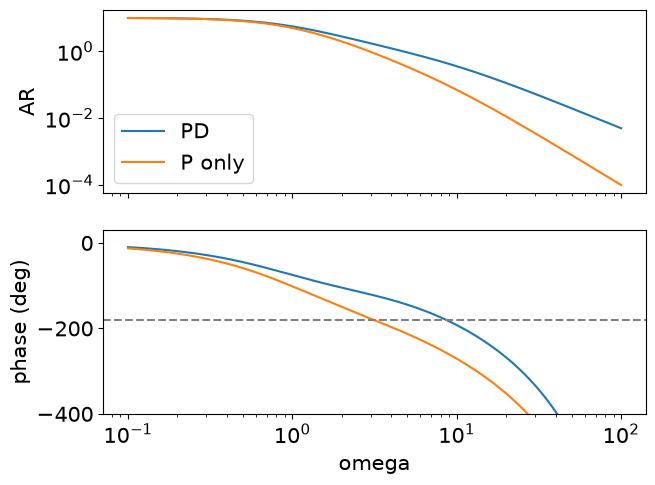

In [13]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7, 5.25), sharex=True)
for pd, lab in [(True, "PD"), (False, "P only")]:
    a1.loglog(ww, abs(G7(ww, pd)), label=lab)
    a2.semilogx(ww, np.degrees(np.unwrap(np.angle(G7(ww, pd)))))
a2.axhline(-180, ls="--", c="gray"); a2.set_ylim(-400, 30)
a1.set_ylabel("AR"); a2.set(xlabel="omega", ylabel="phase (deg)")
a1.legend(); plt.show()

**Code walkthrough.** Both AR curves start at 10 (the gain); the PD curve bends back up at
omega = 2 (its corner) and so stays higher. The phase curves show the
dead time at work: its lag -0.1 omega rad keeps growing, so both phases
fall without limit. The dashed -180 deg line is crossed at 3.14 (P only)
and 8.62 (PD), as computed in the previous cell.

### Build on it -- identify a sensor from phase data (Prob. 15.2)

- Element B lags reference thermocouple A ($\tau_A = 0.1$ min)
- Model: lag $= \tan^{-1}\omega\tau_B - \tan^{-1}0.1\omega$; fit $\tau_B$

In [14]:
f = np.array([0.1, 0.2, 0.4, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0])  # cyc/min
lag = np.array([7.1, 12.9, 21.8, 28.2, 29.8, 26.0, 23.6, 18.0, 14.2])
wf = 2 * np.pi * f                                          # rad/min
def phase_lag(w, tauB):
    return np.degrees(np.arctan(w * tauB) - np.arctan(0.1 * w))
p, cov = curve_fit(phase_lag, wf, lag, p0=[0.5])
print(f"tau_B = {p[0]:.3f} +/- {np.sqrt(cov[0, 0]):.3f} min")
print("residuals (deg):", np.round(lag - phase_lag(wf, *p), 1))

tau_B = 0.290 +/- 0.003 min
residuals (deg): [ 0.4  0.  -0.2 -0.7  0.7 -0.6  0.4  0.4  0.3]


**Code walkthrough.** The book gives the phase lag of B behind A at nine frequencies, in
cycles per minute; `2 * np.pi * f` converts to rad/min. If B is first
order, its lag behind the bath is atan(omega tau_B) and A's is
atan(0.1 omega), so B lags A by the difference: the model. `curve_fit`
finds tau_B = 0.290 +/- 0.003 min; residuals are all under 1 deg -- the
first-order assumption is reasonable, as the problem asks us to show.
A frequency-domain cousin of Lecture 3's tau fit.

### Your Turn (8 min)

1. By hand: a PI controller with $K_c = 2$, $\tau_I = 5$ min. AR and
   phase at $\omega = 0.2$ rad/min.
2. Read the code: which version of Ex. 15.7 would tolerate a larger
   controller gain before the loop goes unstable, and why (one line)?

(1) omega tau_I = 1: AR = 2 sqrt 2 = 2.83, phase = -45 deg.
(2) The PD version: its -180 deg frequency (8.62) has AR 0.44 per unit
gain versus 0.88 at 3.14 for P only, so its gain can be raised about
2x further before AR reaches 1 at -180 deg (Lecture 8's Bode criterion).

### Check -- think-pair-share

In Ex. 15.4 the thermocouple reading lags the inlet temperature by
$188^\circ$ at $\omega = 46$ rad/min. Explain, without equations, why a
proportional controller acting on that reading could make the tank
temperature swing **more** at that frequency.

A 188 deg lag puts the measured swing almost exactly out of phase with
the disturbance: the controller adds heat when the inlet is already hot
and removes it when cold, reinforcing the oscillation. With enough gain
the reinforcement exceeds the attenuation and the loop is unstable
(Fig. 15-11; Ch. 16).

### Wrap-up

**Derived, then coded:** the substitution rule $s \to j\omega$; AR and
phase of first-order, second-order, dead-time, PI and PD blocks; series
rules; resonance; Bode diagrams computed **and measured** from
simulated sine tests; a sensor time constant fitted from phase data.

**Tools:** Python complex numbers, `np.angle`, `np.unwrap`,
`ct.forced_response`, `np.linalg.lstsq`, `curve_fit`

**Next:** Ch. 16 -- the Bode stability criterion, gain and phase
margins, and Ziegler-Nichols tuning.